<a href="https://colab.research.google.com/github/ramirezcarlos292/miaad_python_programming/blob/main/practices/Pr%C3%A1ctica_27_Arboles_de_Decisi%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Objetivo:
Aplicar de forma integral el proceso de entrenamiento, ajuste y evaluación de un clasificador tipo Árbol de Decisión sobre un conjunto de datos grande, aplicando técnicas robustas de validación cruzada y optimización de hiperparámetros.


# 1. Carga de Bibliotecas, Conjunto de Datos

## Cargar bibliotecas

In [25]:
from google.colab import drive
drive.mount('/content/mydrive/')

Drive already mounted at /content/mydrive/; to attempt to forcibly remount, call drive.mount("/content/mydrive/", force_remount=True).


In [26]:
import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score
from scipy.stats import randint

import time
seed = 42

## Conjunto de datos
https://archive.ics.uci.edu/dataset/759/glioma+grading+clinical+and+mutation+features+dataset

In [27]:
!wget -P /content/drive/MyDrive/ClassFiles/ https://raw.githubusercontent.com/ramirezcarlos292/miaad_python_programming/refs/heads/main/datasets/glioma_grading_clinical_and_mutation_features_dataset/TCGA_GBM_LGG_Mutations_all.csv
!wget -P /content/drive/MyDrive/ClassFiles/ https://raw.githubusercontent.com/ramirezcarlos292/miaad_python_programming/refs/heads/main/datasets/glioma_grading_clinical_and_mutation_features_dataset/TCGA_InfoWithGrade.csv

--2025-11-17 05:11:49--  https://raw.githubusercontent.com/ramirezcarlos292/miaad_python_programming/refs/heads/main/datasets/glioma_grading_clinical_and_mutation_features_dataset/TCGA_GBM_LGG_Mutations_all.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 265050 (259K) [text/plain]
Saving to: ‘/content/drive/MyDrive/ClassFiles/TCGA_GBM_LGG_Mutations_all.csv.1’

TCGA_GBM_LGG_Mutati 100%[===================>] 258.84K  --.-KB/s    in 0.03s   

2025-11-17 05:11:50 (7.95 MB/s) - ‘/content/drive/MyDrive/ClassFiles/TCGA_GBM_LGG_Mutations_all.csv.1’ saved [265050/265050]

--2025-11-17 05:11:50--  https://raw.githubusercontent.com/ramirezcarlos292/miaad_python_programming/refs/heads/main/datasets/glioma_grading_clinical_and_mutation_features_dataset/TCGA_InfoWithG

In [28]:
df_raw = pd.read_csv('/content/drive/MyDrive/ClassFiles/TCGA_GBM_LGG_Mutations_all.csv')
df_raw.head()

,Grade,Project,Case_ID,Gender,Age_at_diagnosis,Primary_Diagnosis,Race,IDH1,TP53,ATRX,PTEN,EGFR,CIC,MUC16,PIK3CA,NF1,PIK3R1,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
0,LGG,TCGA-LGG,TCGA-DU-8164,Male,51 years 108 days,"Oligodendroglioma, NOS",white,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,MUTATED,NOT_MUTATED,NOT_MUTATED,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
1,LGG,TCGA-LGG,TCGA-QH-A6CY,Male,38 years 261 days,Mixed glioma,white,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
2,LGG,TCGA-LGG,TCGA-HW-A5KM,Male,35 years 62 days,"Astrocytoma, NOS",white,MUTATED,MUTATED,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
3,LGG,TCGA-LGG,TCGA-E1-A7YE,Female,32 years 283 days,"Astrocytoma, anaplastic",white,MUTATED,MUTATED,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,MUTATED,NOT_MUTATED,NOT_MUTATED,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,MUTATED,NOT_MUTATED
4,LGG,TCGA-LGG,TCGA-S9-A6WG,Male,31 years 187 days,"Astrocytoma, anaplastic",white,MUTATED,MUTATED,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED


In [29]:
dfpp = pd.read_csv('/content/drive/MyDrive/ClassFiles/TCGA_InfoWithGrade.csv')
dfpp.head()

,Grade,Gender,Age_at_diagnosis,Race,IDH1,TP53,ATRX,PTEN,EGFR,CIC,MUC16,PIK3CA,NF1,PIK3R1,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
0,0,0,51.30,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0
1,0,0,38.72,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,35.17,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,1,32.78,0,1,1,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0
4,0,0,31.51,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


# 2. Análisis Exploratorio de los Datos

#### Describir la forma y estructura

In [30]:
dfpp.shape

(839, 24)

In [31]:
dfpp.describe()

,Grade,Gender,Age_at_diagnosis,Race,IDH1,TP53,ATRX,PTEN,EGFR,CIC,MUC16,PIK3CA,NF1,PIK3R1,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
count,839.000000,839.000000,839.000000,839.000000,839.000000,839.000000,839.000000,839.000000,839.000000,839.000000,839.000000,839.000000,839.000000,839.000000,839.000000,839.000000,839.000000,839.000000,839.000000,839.000000,839.000000,839.000000,839.000000,839.000000
mean,0.419547,0.418355,50.935411,0.107271,0.481526,0.414779,0.258641,0.168057,0.133492,0.132300,0.116806,0.087008,0.079857,0.064362,0.053635,0.047676,0.045292,0.034565,0.032181,0.032181,0.032181,0.027414,0.027414,0.026222
std,0.493779,0.493583,15.702339,0.369392,0.499957,0.492978,0.438149,0.374140,0.340309,0.339019,0.321380,0.282015,0.271233,0.245544,0.225431,0.213206,0.208068,0.182784,0.176586,0.176586,0.176586,0.163383,0.163383,0.159889
min,0.000000,0.000000,14.420000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,38.055000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,51.550000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,1.000000,62.800000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,89.290000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [32]:
dfpp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 839 entries, 0 to 838
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Grade             839 non-null    int64  
 1   Gender            839 non-null    int64  
 2   Age_at_diagnosis  839 non-null    float64
 3   Race              839 non-null    int64  
 4   IDH1              839 non-null    int64  
 5   TP53              839 non-null    int64  
 6   ATRX              839 non-null    int64  
 7   PTEN              839 non-null    int64  
 8   EGFR              839 non-null    int64  
 9   CIC               839 non-null    int64  
 10  MUC16             839 non-null    int64  
 11  PIK3CA            839 non-null    int64  
 12  NF1               839 non-null    int64  
 13  PIK3R1            839 non-null    int64  
 14  FUBP1             839 non-null    int64  
 15  RB1               839 non-null    int64  
 16  NOTCH1            839 non-null    int64  
 1

#### Distribución de clases

In [33]:
dfpp['Grade'].value_counts()

,count
Grade,
0,487
1,352


<Axes: xlabel='Grade'>

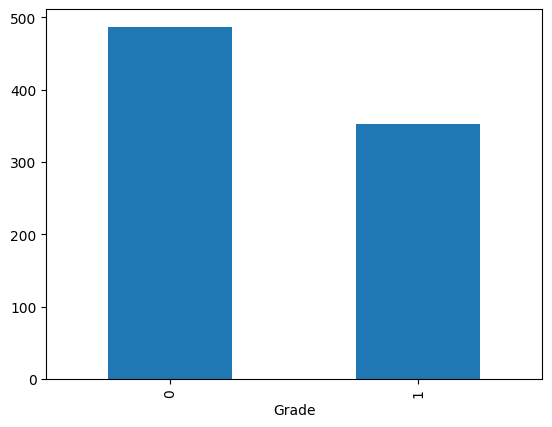

In [34]:
dfpp['Grade'].value_counts().plot.bar()
# 0 LGC, 1 GBM

#### Visualizaciones

<Axes: ylabel='Frequency'>

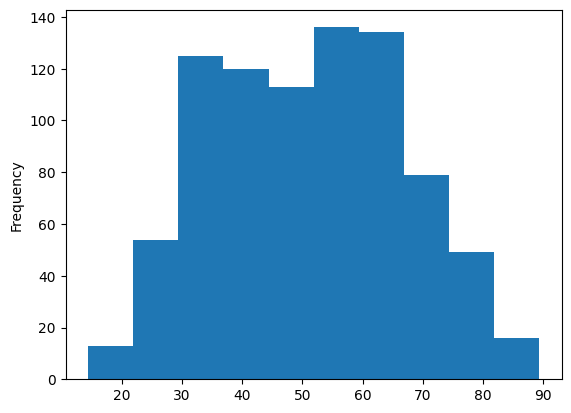

In [35]:
dfpp['Age_at_diagnosis'].plot.hist()

<Axes: xlabel='Gender'>

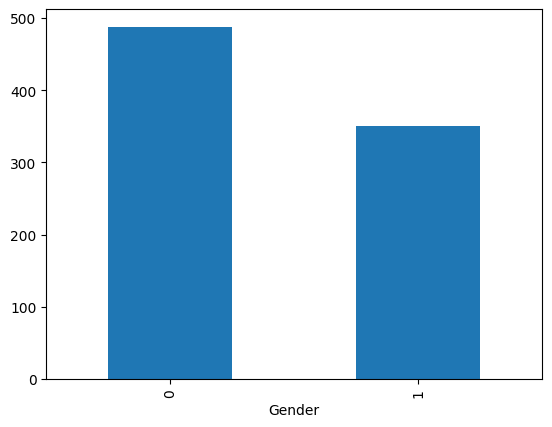

In [36]:
dfpp['Gender'].value_counts().plot.bar()
# 0: Male, 1: Female

<Axes: xlabel='Grade', ylabel='Age_at_diagnosis'>

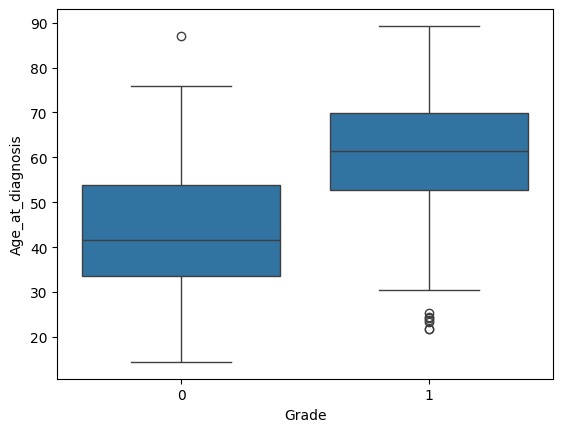

In [37]:
import seaborn as sns

sns.boxplot(dfpp, x='Grade', y='Age_at_diagnosis')

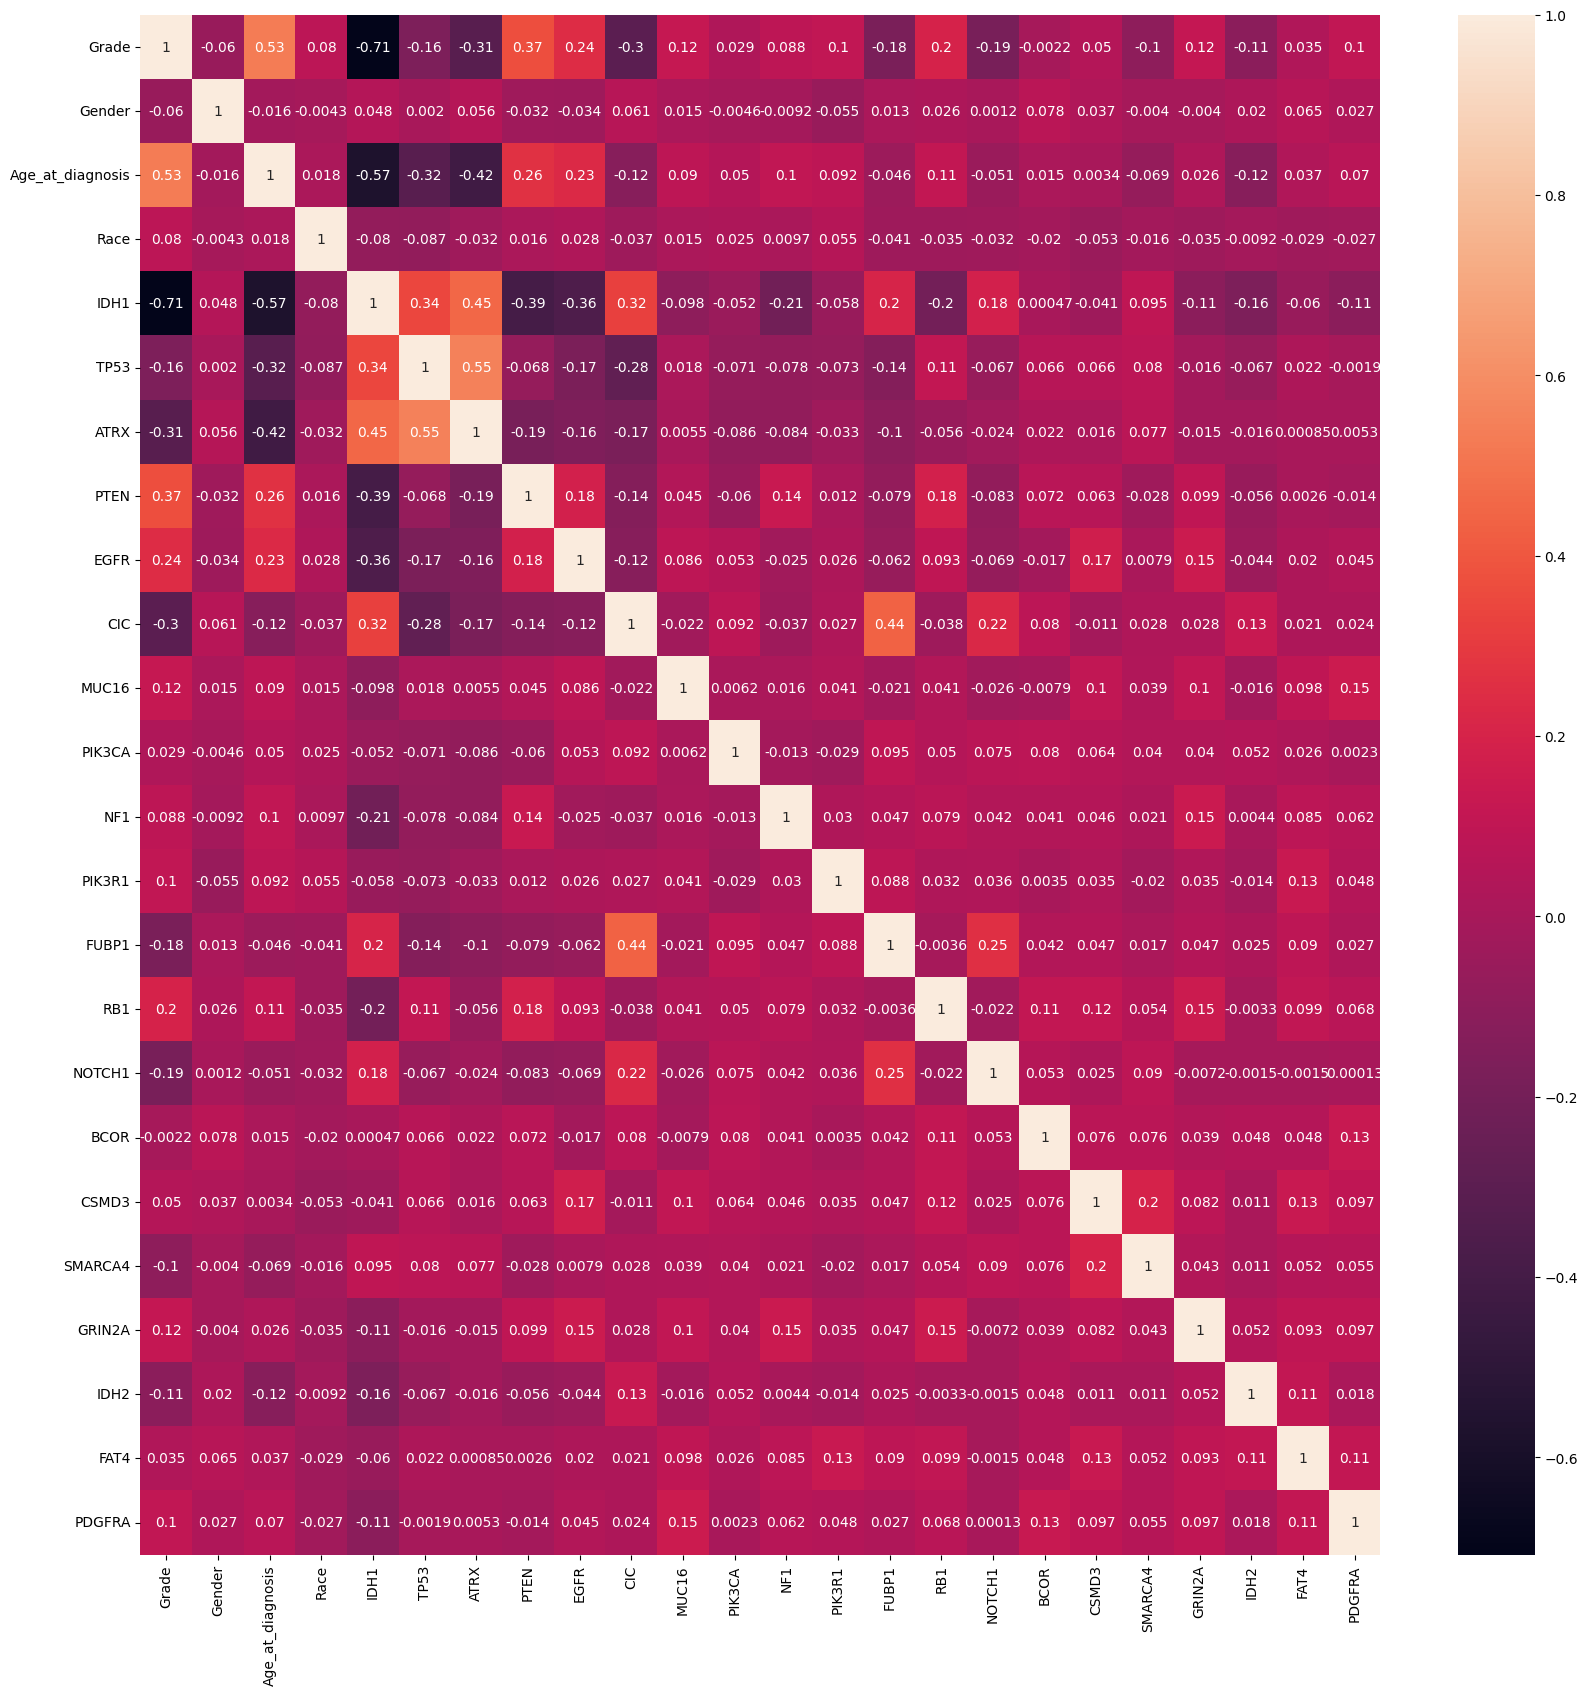

In [38]:
fig = plt.figure(figsize=(20, 20))
sns.heatmap(dfpp.corr(), annot=True)
plt.show()

#### 🧠 Reflexiona:
¿Existen clases desbalanceadas?<br>
No, la categoría 0 es el ~58%, mientras que la categoría 1 es el ~41%.

¿Qué atributos parecen más informativos?


# 3. Gráfica de Errores en Entrenamiento y Prueba

- En este ejercicio vas a entrenar un árbol de decisión con diferentes profundidades. Asimismo, en gráfica mostrarás las exactitudes en entrenamiento y test, usando un stratified k-fold cross-validation con K= 10.
- Los valores de las profundides a evaluar son 2, 5, 10, 15, 20, 25, 30 y None.
- Deberás usar StratifiedKFold con 10 particiones, y un valor aleatorio de 3.
- Entrenarás y evaluarás un árbol de decisión con estos distintos valores de profundidades.
- Usa cross_val_score para entrenar los modelos, usando como métrica de evaluación en scoring="f1_macro",y el StratifiedKFold, con un valor aleatorio = 7.
- Muestra una gráfica para los distintos resultados  cuando se usa F1 Macro.

Depth None: acc_mean 0.7997561675272519


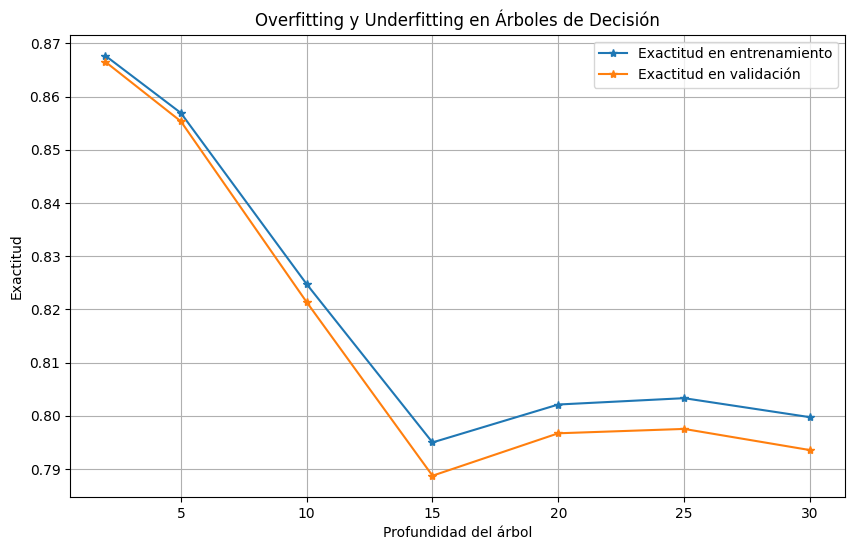

In [39]:
X = dfpp.drop(columns=['Grade'])
y = dfpp['Grade']
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=3)

depths = [2, 5, 10, 15, 20, 25, 30, None]

results = {
    'depth': [],
    'acc_mean': [],
    'cv_score_mean': []
}

for depth in depths:
  clf = DecisionTreeClassifier(max_depth=depth, random_state=7)

  fold_scores = []
  for train_index, test_index in skf.split(X, y):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    fold_acc = accuracy_score(y_test, y_pred)
    fold_scores.append(fold_acc)
  acc_mean = np.mean(fold_scores)

  cv_scores = cross_val_score(clf, X, y, cv=skf, scoring='f1_macro')
  cv_score_mean = np.mean(cv_scores)

  results['depth'].append(depth)
  results['acc_mean'].append(acc_mean)
  results['cv_score_mean'].append(cv_score_mean)

print(f"Depth {depth}: acc_mean {acc_mean}")

plt.figure(figsize=(10,6))
plt.plot(results['depth'], results['acc_mean'], label='Exactitud en entrenamiento', marker='*')
plt.plot(results['depth'], results['cv_score_mean'], label='Exactitud en validación', marker='*')
plt.xlabel('Profundidad del árbol')
plt.ylabel('Exactitud')
plt.title('Overfitting y Underfitting en Árboles de Decisión')
plt.legend()
plt.grid(True)
plt.show()

In [40]:
for idx, val in enumerate(results['depth']):
  print(f"Depth {results['depth'][idx]}: accuracy_mean: {results['acc_mean'][idx]:.4f}, cross val acc {results['cv_score_mean'][idx]:.4f}")

Depth 2: accuracy_mean: 0.8677, cross val acc 0.8665
Depth 5: accuracy_mean: 0.8569, cross val acc 0.8554
Depth 10: accuracy_mean: 0.8248, cross val acc 0.8214
Depth 15: accuracy_mean: 0.7950, cross val acc 0.7888
Depth 20: accuracy_mean: 0.8021, cross val acc 0.7967
Depth 25: accuracy_mean: 0.8033, cross val acc 0.7975
Depth 30: accuracy_mean: 0.7998, cross val acc 0.7936
Depth None: accuracy_mean: 0.7998, cross val acc 0.7936


# 4. Optimización de hiperparámetros con RandomizedSearchCV

- Define el espacio de búsqueda aleatorio para los siguientes hiperpárametros:
  * Criterion = gini ,entropy
  * max_depth: de 5 a 50 con incrementos de 1
  * min_samples_split: de 2 a 20 con incrementos de 1
-Usa el árbol de decisión
-StratifiedKfold = 10 (no deberás realizar ninguna partición previa: realiza el ejercicio considerando que es un conjunto de tamaño medio)
- n_iter = 5 (combinaciones aleatorias a buscar)
- n_jobs = -1 para acelerar cómputo
- Métrica de evaluación: f1 Macro
- Imprime los mejores hiperparámetros encontrados
- Imprime el best_score

In [45]:
from sklearn.metrics import confusion_matrix, classification_report

In [58]:
start = time.time()
param_dist = {
    'criterion': ['gini', 'entropy'],
    'max_depth': randint(1, 51),
    'min_samples_split': randint(2, 21)
}

clf = DecisionTreeClassifier(random_state=7)

cv = StratifiedKFold(n_splits = 10, shuffle=True, random_state=3)

grid_search = RandomizedSearchCV(estimator=clf, param_distributions=param_dist, cv=cv, scoring='f1_macro', n_jobs=-1, random_state=42)

grid_search.fit(X, y)
print(f"Busqueda de hiperparametros tardó: {time.time() - start}")
print("Mejores hiperparámetros encontrados:", grid_search.best_params_)
print("Mejor exactitud promedio (Stratified):", grid_search.best_score_)

Busqueda de hiperparametros tardó: 1.0565760135650635
Mejores hiperparámetros encontrados: {'criterion': 'entropy', 'max_depth': 2, 'min_samples_split': 13}
Mejor exactitud promedio (Stratified): 0.8677010761753141


In [59]:
print(classification_report(y, grid_search.predict(X)))
print(confusion_matrix(y, grid_search.predict(X)))

              precision    recall  f1-score   support

           0       0.94      0.83      0.88       487
           1       0.79      0.93      0.86       352

    accuracy                           0.87       839
   macro avg       0.87      0.88      0.87       839
weighted avg       0.88      0.87      0.87       839

[[402  85]
 [ 25 327]]


# 5. Optimización de hiperparámetros con GridSearchCV

- Define el espacio de búsqueda  para los siguientes hiperpárametros:
  * Criterion = gini ,entropy
  * max_depth: de 5 a 50 con incrementos de 1
  * min_samples_split: de 2 a 20 con incrementos de 1
- Usa el árbol de decisión
- StratifiedKfold = 10 (no deberás realizar ninguna partición previa: realiza el ejercicio considerando que es un conjunto de tamaño medio)
- Métrica de evaluación: f1 Macro
- n_jobs = -1 para acelerar cómputo
- Imprime los mejores hiperparámetros encontrados
- Imprime el best_score

In [60]:
start = time.time()

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [i for i in range(5, 51, 1)],
    'min_samples_split': [i for i in range(2, 21, 1)]
}

clf = DecisionTreeClassifier(random_state=7)

cv = StratifiedKFold(n_splits = 10, shuffle=True, random_state=3)

grid_search = GridSearchCV(estimator=clf, param_grid=param_grid, cv=cv, scoring='f1_macro', n_jobs=-1)

grid_search.fit(X, y)
print(f"Busqueda de hiperparametros tardó: {time.time() - start}")
print("Mejores hiperparámetros encontrados:", grid_search.best_params_)
print("Mejor exactitud promedio (Stratified):", grid_search.best_score_)

Busqueda de hiperparametros tardó: 132.2307949066162
Mejores hiperparámetros encontrados: {'criterion': 'entropy', 'max_depth': 6, 'min_samples_split': 13}
Mejor exactitud promedio (Stratified): 0.8651160144238152


In [61]:
print(classification_report(y, grid_search.predict(X)))
print(confusion_matrix(y, grid_search.predict(X)))

              precision    recall  f1-score   support

           0       0.97      0.82      0.89       487
           1       0.80      0.96      0.87       352

    accuracy                           0.88       839
   macro avg       0.88      0.89      0.88       839
weighted avg       0.90      0.88      0.88       839

[[401  86]
 [ 14 338]]


# 6. Optimización de hiperparámetros con RandomizedSearchCV: Accuracy

- Define el espacio de búsqueda aleatorio para los siguientes hiperpárametros:
  * Criterion = gini ,entropy
  * max_depth: de 5 a 50 con incrementos de 1
  * min_samples_split: de 2 a 20 con incrementos de 1
- Usa el árbol de decisión
- StratifiedKfold = 10 (no deberás realizar ninguna partición previa: realiza el ejercicio considerando que es un conjunto de tamaño medio)
- n_iter = 5 (combinaciones aleatorias a buscar)
- n_jobs = -1 para acelerar cómputo
- Métrica de evaluación: accuracy
- Imprime los mejores hiperparámetros encontrados
- Imprime el best_score

In [43]:
start = time.time()
param_dist = {
    'criterion': ['gini', 'entropy'],
    'max_depth': randint(1, 51),
    'min_samples_split': randint(2, 21)
}

clf = DecisionTreeClassifier(random_state=7)

cv = StratifiedKFold(n_splits = 10, shuffle=True, random_state=3)

grid_search = RandomizedSearchCV(estimator=clf, param_distributions=param_dist, cv=cv, scoring='accuracy', n_jobs=-1, random_state=42)

grid_search.fit(X, y)
print(f"Busqueda de hiperparametros tardó: {time.time() - start}")
print("Mejores hiperparámetros encontrados:", grid_search.best_params_)
print("Mejor exactitud promedio (Stratified):", grid_search.best_score_)


Busqueda de hiperparametros tardó: 1.2234272956848145
Mejores hiperparámetros encontrados: {'criterion': 'entropy', 'max_depth': 2, 'min_samples_split': 13}
Mejor exactitud promedio (Stratified): 0.8688755020080322


# 7. Optimización de hiperparámetros con GridSearchCV: accuracy

- Define el espacio de búsqueda  para los siguientes hiperpárametros:
  * Criterion = gini ,entropy
  * max_depth: de 5 a 50 con incrementos de 1
  * min_samples_split: de 2 a 20 con incrementos de 1
- Usa el árbol de decisión
- StratifiedKfold = 10 (no deberás realizar ninguna partición previa: realiza el ejercicio considerando que es un conjunto de tamaño medio)
- Métrica de evaluación: accuracy
- n_jobs = -1 para acelerar cómputo
- Imprime los mejores hiperparámetros encontrados
- Imprime el best_score

In [44]:
start = time.time()
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [i for i in range(5, 51, 1)],
    'min_samples_split': [i for i in range(2, 21, 1)]
}

clf = DecisionTreeClassifier(random_state=7)

cv = StratifiedKFold(n_splits = 10, shuffle=True, random_state=3)

grid_search = GridSearchCV(estimator=clf, param_grid=param_grid, cv=cv, scoring='accuracy', n_jobs=-1)

grid_search.fit(X, y)
print(f"Busqueda de hiperparametros tardó: {time.time() - start}")
print("Mejores hiperparámetros encontrados:", grid_search.best_params_)
print("Mejor exactitud promedio (Stratified):", grid_search.best_score_)

Busqueda de hiperparametros tardó: 90.88914370536804
Mejores hiperparámetros encontrados: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 13}
Mejor exactitud promedio (Stratified): 0.8664515203671831


# 8.Actividad de reflexión y análisis

- ¿Cuál método encontró mejores hiperparámetros?<br>
  Con la mejor exactitud promedio (Stratified): 0.8688755020080322.
  6. Optimización de hiperparámetros con RandomizedSearchCV: Accuracy<br>
  Mejores hiperparámetros encontrados: {'criterion': 'entropy', 'max_depth': 2, 'min_samples_split': 13}<br>

- ¿Cuál fue más costoso computacionalmente?<br>
  5. Optimización de hiperparámetros con GridSearchCV tardó entre 117 y 137 segundos, dado que tiene que recorrer las listas de hiperparametros.
  
- ¿Los resultados en f1_macro set fueron distintos en ambos métodos de optimización? ¿Por qué?<br>
  * f1_macro ayuda en darle el mismo peso a las clases, RandomizedSearchCV tuvó mejor accuracy y menos profundidad del árbol modelado, mientras que GridSearchCV profundizó más y tuvó overfitting, en cambio RandomizedSearchCV convergió más rápido y con mayor exactitud.
  
- ¿Los resultados en accuracy set fueron distintos en ambos métodos de optimización? ¿Por qué?
  * Similar a lo sucedido en la pregunta anterior, GridSearchCV, continua profundizando el árbol, mientras que RandomizedSearchCV converge mas rápido y sin overfitting dado que no explora todas las combinaciones posibles.
- ¿Los valores de hiperpárametros fueron iguales en Accuracy y F1 Macro ?
  * los hiperpárametros resultaron igual entre GridSearchCV y RandomizedSearchCV, GridSearchCV profundizo más mientras que RandomizedSearchCV convergió más rapido y con una ligera mejora en la exactitud.